In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.feature_selection import f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score, precision_score, f1_score


In [2]:
df = pd.read_csv('../../data/dataset_pv_variability_paca_2020_2024.csv', index_col=0).dropna()
df["is_night"] = (df["ghi_region"] <= 0).astype(int) # Il faut qu'on ajoute cette feature dans le notebook eature engineering


Coefficient alpha estimé : 0.1677
Régression linéaire: MAE=0.8999 | RMSE=1.7001 | R2 =0.7353
le modèle se trompe en moyenne de 36.97% de la valeur moyenne.



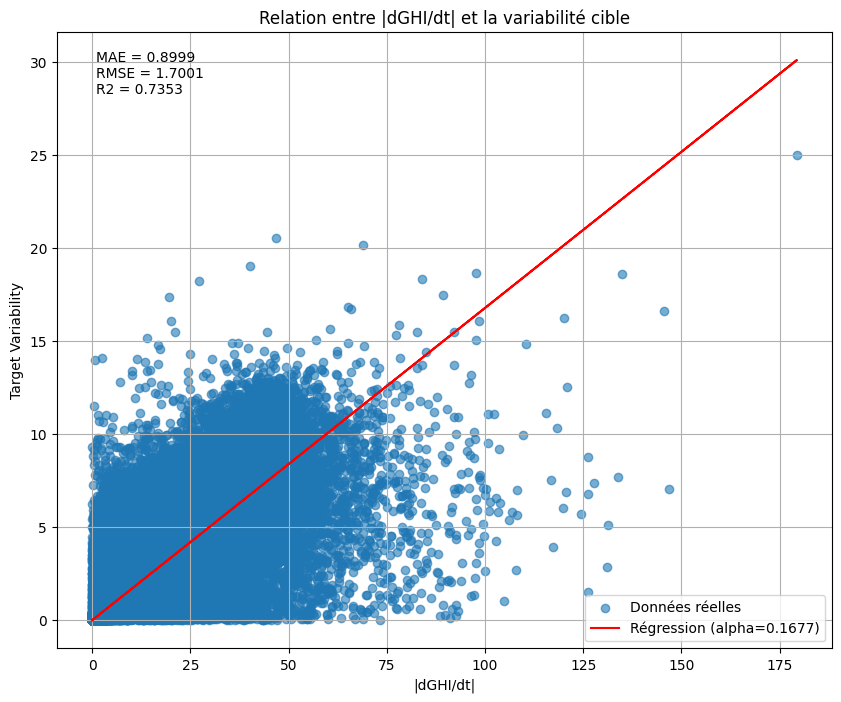

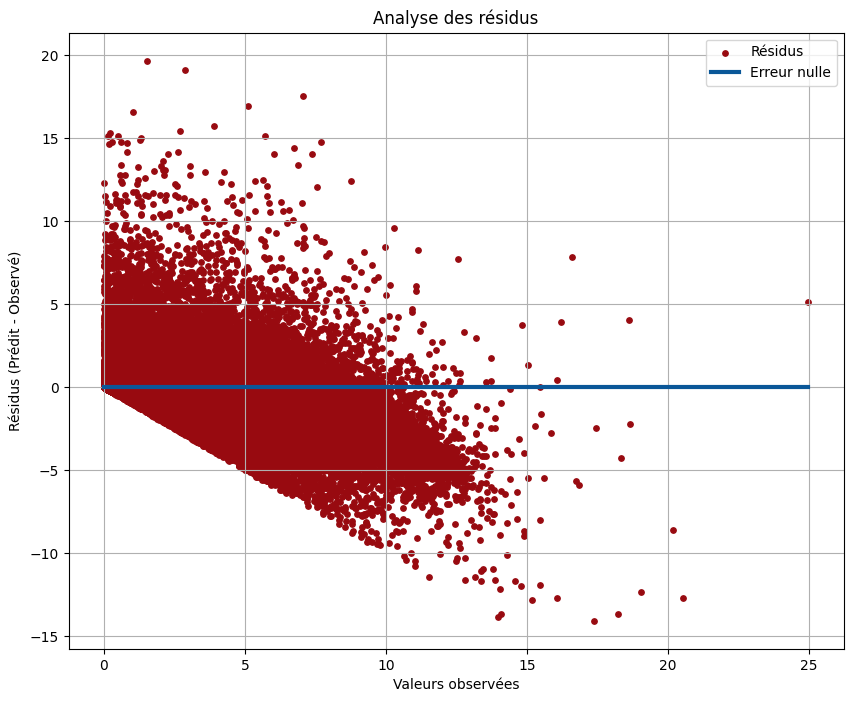

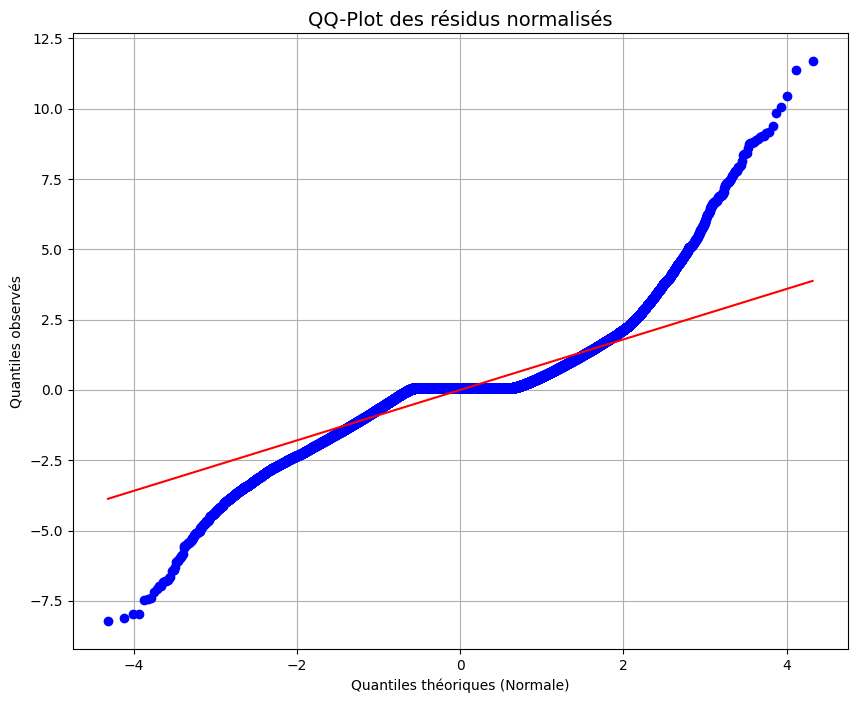

In [3]:
# ==============================
# 1. Régression linéaire simple
# ==============================

# Création du modèle sans intercept (droite passant par l'origine)
lr = LinearRegression(fit_intercept=False)

# Variable explicative : valeur absolue de la dérivée du GHI
X_lr = np.abs(df[["dghi_dt"]].values)

# Variable cible : variabilité à prédire
y_lr = df.target_variability.values

# Entraînement du modèle
lr.fit(X_lr, y_lr)

# Coefficient directeur (alpha)
alpha_lr = lr.coef_[0]
print(f"Coefficient alpha estimé : {alpha_lr:.4f}")

# Prédictions du modèle
pred_lr = lr.predict(X_lr)

# Calcul de l'erreur absolue moyenne
mae_lr = mean_absolute_error(y_lr, pred_lr)
mae_relatif_lr = round(mae_lr / y_lr.mean() * 100, 2)
mse_lr = mean_squared_error(y_lr, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_lr, pred_lr)
print(f"Régression linéaire: MAE={mae_lr:.4f} | RMSE={rmse_lr:.4f} | R2 ={r2_lr:.4f}")
print(f"le modèle se trompe en moyenne de {mae_relatif_lr}% de la valeur moyenne.\n")


# ==============================
# 2️. Graphique : Données + Droite ajustée
# ==============================

plt.figure(figsize=(10, 8))

# Nuage de points réel
plt.scatter(X_lr, y_lr, label="Données réelles", alpha=0.6)

# Droite de régression
plt.plot(X_lr, pred_lr, c='red', label=f"Régression (alpha={alpha_lr:.4f})")

plt.xlabel('|dGHI/dt|')
plt.ylabel('Target Variability')
plt.title('Relation entre |dGHI/dt| et la variabilité cible')
plt.legend()
plt.grid(True)

# Annotation du MAE
plt.annotate(f"MAE = {mae_lr:.4f}\nRMSE = {rmse_lr:.4f}\nR2 = {r2_lr:.4f}",
             xy=(0.05, 0.9),
             xycoords='axes fraction')

plt.show()


# ==============================
# 3️. Analyse des résidus
# ==============================

# Calcul des résidus
residus = pred_lr - y_lr

plt.figure(figsize=(10, 8))

# Résidus vs valeurs observées
plt.scatter(y_lr, residus, color='#980a10', s=15, label="Résidus")

# Ligne horizontale à 0
plt.plot((y_lr.min(), y_lr.max()), (0, 0),
         lw=3, color='#0a5798', label="Erreur nulle")

plt.xlabel("Valeurs observées")
plt.ylabel("Résidus (Prédit - Observé)")
plt.title("Analyse des résidus")
plt.legend()
plt.grid(True)
plt.show()
# Commentaire: les points sont répartis aléatoirement autour de 0.


# ==============================
# 4️. QQ-plot (Normalité des résidus)
# ==============================

plt.figure(figsize=(10, 8))

# Normalisation des résidus
residus_norm = (residus - residus.mean()) / residus.std()

# QQ-plot
stats.probplot(residus_norm, plot=plt)

plt.title("QQ-Plot des résidus normalisés", fontsize=14)
plt.xlabel("Quantiles théoriques (Normale)")
plt.ylabel("Quantiles observés")
plt.grid(True)

# Commentaire: les points suivent approximativement la droite,
# les résidus peuvent être considérés comme normalement distribués.

plt.show()


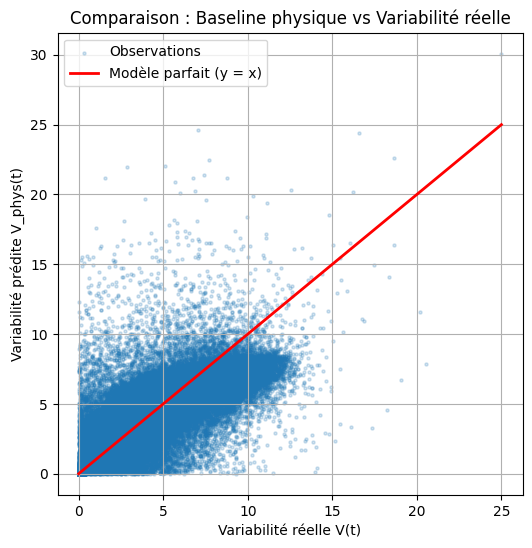

In [4]:
# Calcul de la variabilité prédite par le modèle physique
# Hypothèse : V_phys = alpha * |dGHI/dt|
df["V_phys"] = alpha_lr * np.abs(df["dghi_dt"])

# Comparaison : Réel vs Modèle Physique
plt.figure(figsize=(6, 6))

# Nuage de points : valeurs réelles vs prédiction physique
plt.scatter(df["target_variability"],
            df["V_phys"],
            s=5,
            alpha=0.2,
            label="Observations")

# Droite identité y = x (modèle parfait)
plt.plot([0, 25], [0, 25],
         color="red",
         linewidth=2,
         label="Modèle parfait (y = x)")

plt.xlabel("Variabilité réelle V(t)")
plt.ylabel("Variabilité prédite V_phys(t)")
plt.title("Comparaison : Baseline physique vs Variabilité réelle")

plt.legend()
plt.grid(True)
plt.show()


In [5]:
# Test de significativité du coefficient: ce test correspond au test F en régression linéaire
# Il teste si le coefficient associé à |dGHI/dt| est significativement différent de 0.

# Hypothèses :
# H0 : Le coefficient alpha = 0  → |dGHI/dt| n'explique pas target_variability
# H1 : Le coefficient alpha ≠ 0 → |dGHI/dt| explique significativement target_variability

f_statistic, p_values = f_regression(X_lr, y_lr)

print(f"Statistique F = {f_statistic[0]:.2f}")
print(f"p-value = {p_values[0]:.16f}")

# Interprétation automatique
if p_values[0] < 0.05:
    print("On rejette H0 : |dGHI/dt| est statistiquement significatif.")
else:
    print("On ne rejette pas H0 : variable non significative.")


Statistique F = 247054.79
p-value = 0.0000000000000000
On rejette H0 : |dGHI/dt| est statistiquement significatif.


La valeur élevée de la statistique F (F = 247054.79) indique que la part de variance expliquée par le modèle est très importante par rapport à la variance résiduelle. Par ailleurs, une p-valeur nulle (inférieure à 0.05) montre que la variable explicative |dGHI/dt| apporte une contribution statistiquement significative au modèle.

### Capacité prédictive réelle: est-ce que le modèle généralise dans le temps ?

Alpha estimé sur TRAIN = 0.164283
Alpha estimé sur VALID = 0.171504

TRAIN: MAE=0.8807 | RMSE=1.6501 | R²=0.7369
Le modèle se trompe en moyenne de 37.3871% de la valeur moyenne.

VALIDATION: MAE=0.8868 | RMSE=1.6610 | R²=0.7560
Le modèle se trompe en moyenne de 35.4827% de la valeur moyenne.

TEST: MAE=0.9368 | RMSE=1.7714 | R²=0.7219
Le modèle se trompe en moyenne de 37.7622% de la valeur moyenne.



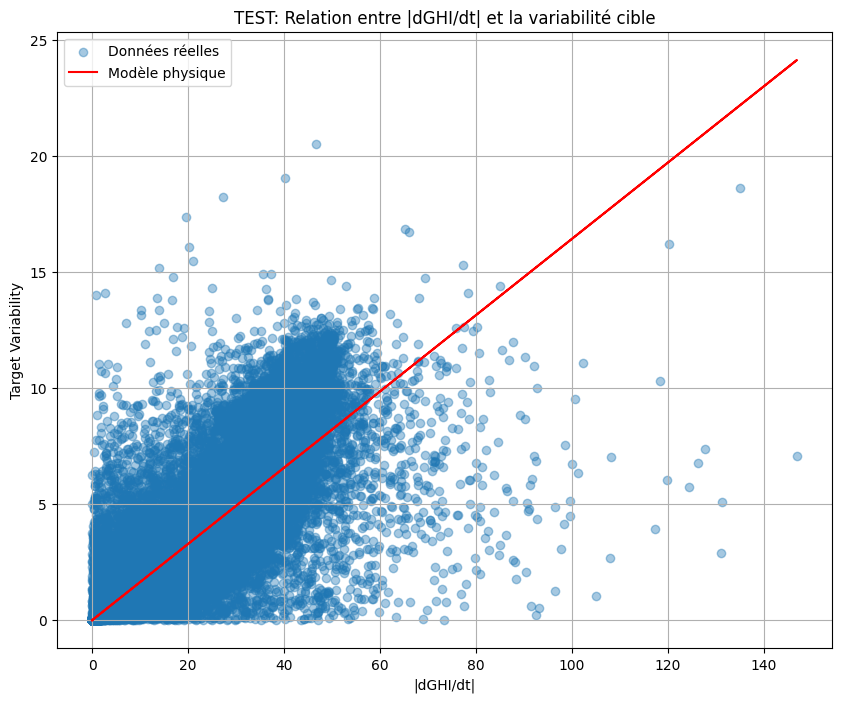

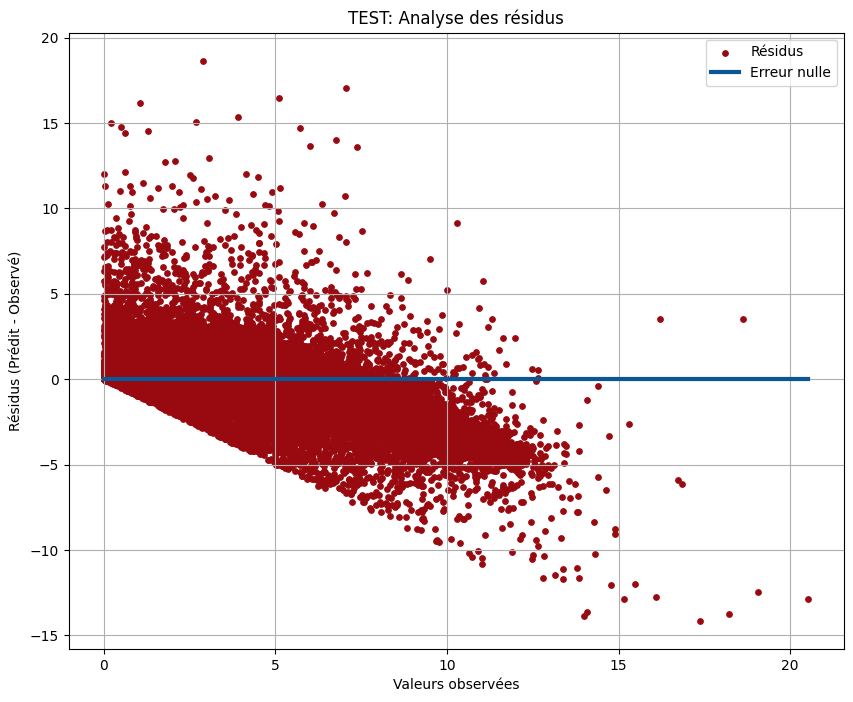

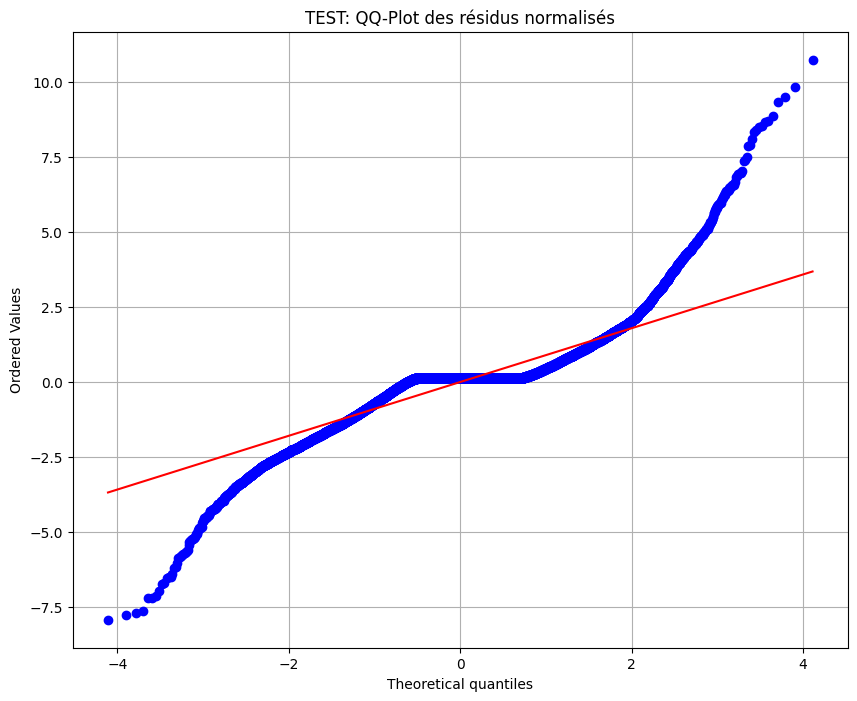

In [6]:
# ============================================
# Split temporel des données
# ============================================

# Séparation chronologique :
train = df.loc[df['year'] < 2022].copy()
valid = df.loc[df['year'] == 2022].copy()
test  = df.loc[df['year'] > 2022].copy()


# ===============================
# Entraînement du modèle physique
# ===============================

# Baseline physique : V = alpha * |dGHI/dt|

X_train = np.abs(train[["dghi_dt"]].values)
y_train = train["target_variability"].values

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# Estimer alpha sur TRAIN
alpha_train = model.coef_[0]

# Estimer alpha uniquement sur VALID
X_valid = np.abs(valid[["dghi_dt"]].values)
y_valid = valid["target_variability"].values

model_valid = LinearRegression(fit_intercept=False)
model_valid.fit(X_valid, y_valid)
alpha_valid = model_valid.coef_[0]

print(f"Alpha estimé sur TRAIN = {alpha_train:.6f}")
print(f"Alpha estimé sur VALID = {alpha_valid:.6f}\n")


# ==============================================================================
# Fonction d'évaluation: évalue les performances du modèle sur un sous-ensemble
# ==============================================================================

def eval_split(name, split):
    X = np.abs(split[["dghi_dt"]].values)
    y = split["target_variability"].values
    
    pred = model.predict(X)
    
    mae = mean_absolute_error(y, pred)
    mae_relatif = mae / y.mean() * 100
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    
    print(f"{name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    print(f"Le modèle se trompe en moyenne de {mae_relatif:.4f}% de la valeur moyenne.\n")


# Évaluation sur chaque split
eval_split("TRAIN", train)
eval_split("VALIDATION", valid)
eval_split("TEST", test)


# ==========================
# Analyse graphique sur TEST
# ==========================

X = np.abs(test[["dghi_dt"]].values)
y = test["target_variability"].values
pred = model.predict(X)
residus = pred - y


# ---------------------------------------
# Graphique 1 : Données + Droite ajustée
# ---------------------------------------

plt.figure(figsize=(10, 8))

plt.scatter(X, y, alpha=0.4, label="Données réelles")
plt.plot(X, pred, c='red', label="Modèle physique")

plt.xlabel('|dGHI/dt|')
plt.ylabel('Target Variability')
plt.title('TEST: Relation entre |dGHI/dt| et la variabilité cible')
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------
# Graphique 2 : Analyse des résidus
# -------------------------------------------------

plt.figure(figsize=(10, 8))

plt.scatter(y, residus, color='#980a10', s=15, label="Résidus")
plt.plot((y.min(), y.max()), (0, 0), lw=3, color='#0a5798', label="Erreur nulle")

plt.xlabel("Valeurs observées")
plt.ylabel("Résidus (Prédit - Observé)")
plt.title("TEST: Analyse des résidus")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------
# Graphique 3 : QQ-Plot (normalité des résidus)
# -------------------------------------------------

plt.figure(figsize=(10, 8))

residus_norm = (residus - residus.mean()) / residus.std()
stats.probplot(residus_norm, plot=plt)

plt.title("TEST: QQ-Plot des résidus normalisés")
plt.grid(True)
plt.show()


In [7]:
# Variables explicatives utilisées
features = [
    "dghi_dt",
    "dcloud_dt",
    "sin_hour",
    "cos_hour",
    "is_night",
    # "toa_irradiance_region"
]

# Création des matrices X
X_train = train[features].copy()
X_valid = valid[features].copy()
X_test  = test[features].copy()

# On prend les valeurs absolues des variations
# car la variabilité dépend de l’intensité du changement,
# pas de sa direction.
for col in ["dghi_dt", "dcloud_dt"]:
    X_train[col] = np.abs(X_train[col])
    X_valid[col] = np.abs(X_valid[col])
    X_test[col]  = np.abs(X_test[col])

# Variable cible
y_train = train["target_variability"]
y_valid = valid["target_variability"]
y_test  = test["target_variability"]

# Modèle linéaire multiple (avec intercept)
# Contrairement au modèle physique précédent,
# on autorise ici une constante (biais).
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Fonction d’évaluation
def eval_model(name, X, y):
    pred = model2.predict(X)
    mae = mean_absolute_error(y, pred)
    mae_relatif = round(mae / y.mean() * 100, 2)
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)
    print(f"{name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
    print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne.\n")

# Évaluation
eval_model("TRAIN", X_train, y_train)
eval_model("VAL", X_valid, y_valid)
eval_model("TEST", X_test, y_test)


TRAIN: MAE=0.9276 | RMSE=1.6159 | R2 =0.7477
le modèle se trompe en moyenne de 39.38% de la valeur moyenne.

VAL: MAE=0.9335 | RMSE=1.6281 | R2 =0.7655
le modèle se trompe en moyenne de 37.35% de la valeur moyenne.

TEST: MAE=0.9786 | RMSE=1.7278 | R2 =0.7355
le modèle se trompe en moyenne de 39.45% de la valeur moyenne.



In [8]:

features = [
    "dghi_dt",
    "dcloud_dt",
    "sin_hour",
    "cos_hour",
    "is_night",
    # "toa_irradiance_region",
    # "solar_altitude_region"
]

def train_and_eval(target):
    """
    Entraîne un Gradient Boosting Regressor
    et évalue ses performances sur TRAIN / VAL / TEST
    """
    # Modèle non-linéaire (boosting)
    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )

    # Séparation des données
    X_train = train[features]
    y_train = train[target]

    X_val = valid[features]
    y_val = valid[target]

    X_test = test[features]
    y_test = test[target]

    model.fit(X_train, y_train)

    # Évaluation
    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target} | {name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Évaluation
train_and_eval("target_variability")



target_variability | TRAIN: MAE=0.6939 | RMSE=1.2323 | R2 =0.8533
le modèle se trompe en moyenne de 29.46% de la valeur moyenne

target_variability | VAL: MAE=0.7026 | RMSE=1.2812 | R2 =0.8548
le modèle se trompe en moyenne de 28.11% de la valeur moyenne

target_variability | TEST: MAE=0.7478 | RMSE=1.3722 | R2 =0.8331
le modèle se trompe en moyenne de 30.14% de la valeur moyenne



Le Gradient Boosting:
- Capture les non-linéarités
- Capture les interactions entre variables
- Gère mieux les effets seuil
- Est robuste aux distributions asymétriques

In [9]:
# Modèle XGBoost
def train_and_eval_xgb(target):

    model = XGBRegressor(
        n_estimators=300,      # nombre d'arbres
        max_depth=4,           # profondeur des arbres
        learning_rate=0.05,    # taux d'apprentissage
        subsample=0.8,         # échantillonnage des lignes
        colsample_bytree=0.8,  # échantillonnage des variables
        reg_lambda=1,          # régularisation L2
        random_state=42
    )

    # Séparation des données
    X_train = train[features]
    y_train = train[target]

    X_val = valid[features]
    y_val = valid[target]

    X_test = test[features]
    y_test = test[target]

    model.fit(X_train, y_train)

    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target} | {name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Évaluation
train_and_eval_xgb("target_variability")


target_variability | TRAIN: MAE=0.6481 | RMSE=1.1808 | R2 =0.8653
le modèle se trompe en moyenne de 27.51% de la valeur moyenne

target_variability | VAL: MAE=0.6649 | RMSE=1.2460 | R2 =0.8627
le modèle se trompe en moyenne de 26.6% de la valeur moyenne

target_variability | TEST: MAE=0.7113 | RMSE=1.3425 | R2 =0.8403
le modèle se trompe en moyenne de 28.67% de la valeur moyenne



In [10]:
# Modèle Random Forest
def train_and_eval_rf(target):

    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # Séparation des données
    X_train = train[features]
    y_train = train[target]

    X_val = valid[features]
    y_val = valid[target]

    X_test = test[features]
    y_test = test[target]

    model.fit(X_train, y_train)

    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Évaluation
train_and_eval_rf("target_variability")


target_variability: MAE=0.5764 | RMSE=1.0823 | R2 =0.8868
le modèle se trompe en moyenne de 24.47% de la valeur moyenne

target_variability: MAE=0.6555 | RMSE=1.2588 | R2 =0.8598
le modèle se trompe en moyenne de 26.23% de la valeur moyenne

target_variability: MAE=0.7010 | RMSE=1.3513 | R2 =0.8382
le modèle se trompe en moyenne de 28.26% de la valeur moyenne



In [11]:
# Création des horizons de prévision
# Horizon 30 minutes
df["V_future_30min"] = df["target_variability"].shift(-1)

# Horizon 1 heure
df["V_future_1h"]    = df["target_variability"].shift(-2)


# Variables retardées (mémoire du système)

# Production passée (inertie système)
df["tch_lag_1"] = df["tch"].shift(1)
df["tch_lag_2"] = df["tch"].shift(2)
df["tch_lag_3"] = df["tch"].shift(3)

# Variations irradiance passées
df["dghi_lag_1"] = df["dghi_dt"].shift(1)
df["dghi_lag_2"] = df["dghi_dt"].shift(2)

# Nettoyage des NaN générés par les shifts
df_ml = df.dropna().reset_index(drop=True)

features = [
    "dghi_dt",
    "dcloud_dt",
    "cloud_lag_1",
    "cloud_lag_2",
    # "sin_hour",
    # "cos_hour",
    # "sin_doy",
    # "cos_doy",
    "is_night",
    "tch_lag_1",
    "tch_lag_2",
    "tch_lag_3",
    # "ghi_lag_1",
    # "ghi_lag_2",
    "dghi_lag_1",
    "dghi_lag_2"
]

train_ml = df_ml.loc[df_ml['year'] < 2022].copy()
valid_ml = df_ml.loc[df_ml['year'] == 2022].copy()
test_ml  = df_ml.loc[df_ml['year'] > 2022].copy()

def train_and_eval(target):

    model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )

    X_train = train_ml[features]
    y_train = train_ml[target]

    X_val = valid_ml[features]
    y_val = valid_ml[target]

    X_test = test_ml[features]
    y_test = test_ml[target]

    model.fit(X_train, y_train)

    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target} | {name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Variabilité instantanée
train_and_eval("target_variability")

# Forecast 30 minutes
train_and_eval("V_future_30min")

# Forecast 1 heure
train_and_eval("V_future_1h")


target_variability | TRAIN: MAE=0.5267 | RMSE=1.0000 | R2 =0.9034
le modèle se trompe en moyenne de 22.36% de la valeur moyenne

target_variability | VAL: MAE=0.5483 | RMSE=1.0466 | R2 =0.9031
le modèle se trompe en moyenne de 21.94% de la valeur moyenne

target_variability | TEST: MAE=0.6028 | RMSE=1.1714 | R2 =0.8784
le modèle se trompe en moyenne de 24.3% de la valeur moyenne

V_future_30min | TRAIN: MAE=0.6001 | RMSE=1.0993 | R2 =0.8832
le modèle se trompe en moyenne de 25.47% de la valeur moyenne

V_future_30min | VAL: MAE=0.6249 | RMSE=1.1650 | R2 =0.8799
le modèle se trompe en moyenne de 25.0% de la valeur moyenne

V_future_30min | TEST: MAE=0.6733 | RMSE=1.2666 | R2 =0.8578
le modèle se trompe en moyenne de 27.14% de la valeur moyenne

V_future_1h | TRAIN: MAE=0.6869 | RMSE=1.2125 | R2 =0.8579
le modèle se trompe en moyenne de 29.16% de la valeur moyenne

V_future_1h | VAL: MAE=0.7225 | RMSE=1.3082 | R2 =0.8486
le modèle se trompe en moyenne de 28.91% de la valeur moyenne

V_fu

In [12]:
def train_and_eval_rf(target):

    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    X_train = train_ml[features]
    y_train = train_ml[target]

    X_val = valid_ml[features]
    y_val = valid_ml[target]

    X_test = test_ml[features]
    y_test = test_ml[target]

    model.fit(X_train, y_train)

    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Variabilité instantanée
train_and_eval_rf("target_variability")

# Forecast 30 minutes
train_and_eval_rf("V_future_30min")

# Forecast 1 heure
train_and_eval_rf("V_future_1h")

target_variability: MAE=0.4445 | RMSE=0.8968 | R2 =0.9223
le modèle se trompe en moyenne de 18.87% de la valeur moyenne

target_variability: MAE=0.4990 | RMSE=1.0087 | R2 =0.9100
le modèle se trompe en moyenne de 19.96% de la valeur moyenne

target_variability: MAE=0.5658 | RMSE=1.1526 | R2 =0.8823
le modèle se trompe en moyenne de 22.81% de la valeur moyenne

V_future_30min: MAE=0.4977 | RMSE=0.9776 | R2 =0.9077
le modèle se trompe en moyenne de 21.13% de la valeur moyenne

V_future_30min: MAE=0.5672 | RMSE=1.1276 | R2 =0.8875
le modèle se trompe en moyenne de 22.69% de la valeur moyenne

V_future_30min: MAE=0.6197 | RMSE=1.2315 | R2 =0.8656
le modèle se trompe en moyenne de 24.98% de la valeur moyenne

V_future_1h: MAE=0.5679 | RMSE=1.0552 | R2 =0.8924
le modèle se trompe en moyenne de 24.1% de la valeur moyenne

V_future_1h: MAE=0.6553 | RMSE=1.2326 | R2 =0.8656
le modèle se trompe en moyenne de 26.22% de la valeur moyenne

V_future_1h: MAE=0.7099 | RMSE=1.3286 | R2 =0.8436
le modèl

In [13]:
# Modèle XGBoost
def train_and_eval_xgb(target):

    model = XGBRegressor(
        n_estimators=300,      # nombre d'arbres
        max_depth=4,           # profondeur des arbres
        learning_rate=0.05,    # taux d'apprentissage
        subsample=0.8,         # échantillonnage des lignes
        colsample_bytree=0.8,  # échantillonnage des variables
        reg_lambda=1,          # régularisation L2
        random_state=42
    )

    # Séparation des données
    X_train = train_ml[features]
    y_train = train_ml[target]

    X_val = valid_ml[features]
    y_val = valid_ml[target]

    X_test = test_ml[features]
    y_test = test_ml[target]

    model.fit(X_train, y_train)

    for name, X, y in [
        ("TRAIN", X_train, y_train),
        ("VAL", X_val, y_val),
        ("TEST", X_test, y_test)
    ]:
        pred = model.predict(X)
        mae = mean_absolute_error(y, pred)
        mae_relatif = round(mae / y.mean() * 100, 2)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, pred)
        print(f"{target} | {name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2 ={r2:.4f}")
        print(f"le modèle se trompe en moyenne de {mae_relatif}% de la valeur moyenne\n")

# Évaluation
# Variabilité instantanée
train_and_eval_xgb("target_variability")

# Forecast 30 minutes
train_and_eval_xgb("V_future_30min")

# Forecast 1 heure
train_and_eval_xgb("V_future_1h")


target_variability | TRAIN: MAE=0.4715 | RMSE=0.9118 | R2 =0.9197
le modèle se trompe en moyenne de 20.01% de la valeur moyenne

target_variability | VAL: MAE=0.5038 | RMSE=0.9876 | R2 =0.9137
le modèle se trompe en moyenne de 20.16% de la valeur moyenne

target_variability | TEST: MAE=0.5580 | RMSE=1.1275 | R2 =0.8874
le modèle se trompe en moyenne de 22.49% de la valeur moyenne

V_future_30min | TRAIN: MAE=0.5287 | RMSE=1.0099 | R2 =0.9015
le modèle se trompe en moyenne de 22.44% de la valeur moyenne

V_future_30min | VAL: MAE=0.5676 | RMSE=1.1133 | R2 =0.8904
le modèle se trompe en moyenne de 22.71% de la valeur moyenne

V_future_30min | TEST: MAE=0.6236 | RMSE=1.2269 | R2 =0.8666
le modèle se trompe en moyenne de 25.13% de la valeur moyenne

V_future_1h | TRAIN: MAE=0.6189 | RMSE=1.1148 | R2 =0.8799
le modèle se trompe en moyenne de 26.27% de la valeur moyenne

V_future_1h | VAL: MAE=0.6713 | RMSE=1.2442 | R2 =0.8631
le modèle se trompe en moyenne de 26.86% de la valeur moyenne

V_

In [14]:

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train sur horizon principal (30 min)
model.fit(train_ml[features], train_ml["V_future_30min"])

# Importance
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp)


       feature  importance
4     is_night    0.516864
0      dghi_dt    0.259806
7    tch_lag_3    0.072764
5    tch_lag_1    0.036827
9   dghi_lag_2    0.031998
6    tch_lag_2    0.027456
8   dghi_lag_1    0.024206
2  cloud_lag_1    0.012084
3  cloud_lag_2    0.010929
1    dcloud_dt    0.007065


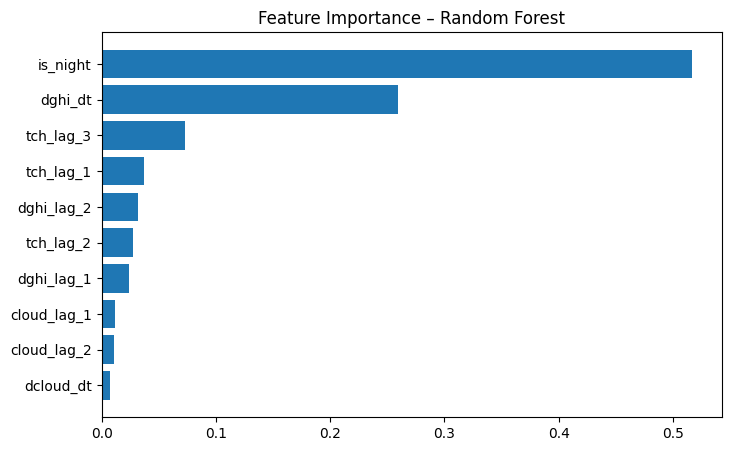

In [15]:
plt.figure(figsize=(8,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance – Random Forest")
plt.show()


In [16]:
threshold = df["target_variability"].quantile(0.95)
print("Seuil Q95 =", threshold)


Seuil Q95 = 9.47


In [17]:

# Prédictions TEST
pred = model.predict(test_ml[features])

y_true = test_ml["V_future_30min"]

# Classification rampes
y_true_event = (y_true >= threshold).astype(int)
y_pred_event = (pred >= threshold).astype(int)


In [22]:
recall = recall_score(y_true_event, y_pred_event)
precision = precision_score(y_true_event, y_pred_event)
f1 = f1_score(y_true_event, y_pred_event)

print("Recall =", recall)
print("Precision =", precision)
print("F1 =", f1)


Recall = 0.4449042938437662
Precision = 0.7825295723384895
F1 = 0.5672823218997362
